In [5]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
matplotlib.use('Agg')

from dataclasses import dataclass
from torch.distributions import Gamma, Multinomial, Dirichlet, Beta, Binomial
from tqdm.auto import tqdm

import os
import sys
from path import Path
current_directory = os.getcwd()
parent_directory = Path(current_directory).parent
sys.path.append(parent_directory)
from apf.base.sample import Sampler
from GS_DPGM import HGPDR,config,CRT
from scipy.stats import poisson
%load_ext Cython
%load_ext autoreload
%autoreload 2

The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
test = np.load('/home/HuangRui/PointProcess/NodeGroup/data/icews_tensor_preprocessed_33610010013.npz', allow_pickle=True)

In [3]:
from GS_PRGDS_Interval_Tensor import GS_PRGDS_tensor
# run model
burnin = 60
maxiter = 40
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.,
'epsilon_lam': 1.,
'stationary': True,
'data' : torch.tensor(test['data'][:108]),
'K' : 50, # latent components
'S' : 54, # sub-intervals
'parallel':True
}

gs_prgds = GS_PRGDS_tensor(**params)
expectation_collection = []
transition_steady = []
for iter in tqdm(range(burnin+maxiter)):
    gs_prgds.sample_n()
    gs_prgds.sample_h()
    gs_prgds.sample_the()
    gs_prgds.sample_lam()
    gs_prgds.sample_delt()
    gs_prgds.sample_g()
    gs_prgds.sample_gam()
    gs_prgds.sample_beta()
    gs_prgds.sample_phi()
    gs_prgds.sample_pi()
    gs_prgds.sample_eta()
    gs_prgds.sample_tilde_hskk()
    gs_prgds.sample_Z()
    gs_prgds.sample_D()
    gs_prgds.sample_dpgm()

    # compute expectation of training data
    part1 = torch.einsum('ik, jk, lk -> ijlk', gs_prgds.phi[0], gs_prgds.phi[1], gs_prgds.phi[2])
    part2 = torch.einsum('k, tk, t -> kt', gs_prgds.lam, gs_prgds.the, gs_prgds.delt)
    expectation = torch.einsum('ijlk, kt -> ijlt', part1, part2)
    expectation_collection.append(expectation.clone())

    if iter > burnin:
        transition_steady.append(gs_prgds.pi.clone())

  0%|          | 0/100 [00:00<?, ?it/s]

sample_n took 97.6693 seconds
The total num of h_tk: tensor(0)
sample_h took 2.5944 seconds
sample_the took 0.0018 seconds
sample_lam took 0.0012 seconds
sample_delt took 0.0183 seconds
sample_g took 0.0090 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 7.7356 seconds
sample_pi took 0.2862 seconds
sample_eta took 0.0017 seconds
The total num of h_tkk:  tensor(45881)
sample_tilde_hskk took 0.0292 seconds
sample_Z took 0.0072 seconds
sample_D took 0.0020 seconds
sample_dpgm took 47.4595 seconds
sample_n took 97.0626 seconds
The total num of h_tk: tensor(45881)
sample_h took 2.3482 seconds
sample_the took 0.0025 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0209 seconds
sample_g took 0.0025 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 4.9002 seconds
sample_pi took 0.2861 seconds
sample_eta took 0.0017 seconds
The total num of h_tkk:  tensor(352781)
sample_tilde_hskk took 0.5006 seconds
sample_Z t

In [4]:
np.save('expectation_collection_gs_prgds_100iter.npy', torch.stack(expectation_collection))

In [6]:
# compute negative log likelihood
negll_collection = []
truth_count = torch.tensor(test['data'][:108]).permute(1,2,3,0)
for expectation in tqdm(expectation_collection):
    pmf = poisson.pmf(truth_count, expectation) 
    negll = np.sum(-np.log(pmf + 1e-32))
    negll_collection.append(np.copy(negll))

  0%|          | 0/100 [00:00<?, ?it/s]

In [7]:
negll_collection

[array(5425156.44686732),
 array(8402752.96434237),
 array(8869308.74958604),
 array(9017621.3789993),
 array(9041980.89907538),
 array(9017365.28591725),
 array(9280741.07593023),
 array(9136893.23921625),
 array(8638130.84751721),
 array(8942413.48389763),
 array(9221821.75783845),
 array(9247915.18203387),
 array(9087022.82805065),
 array(9470569.65622805),
 array(8953510.2691831),
 array(9226643.82953737),
 array(9169226.66211813),
 array(9317866.87737133),
 array(9292645.66643974),
 array(9219821.58188198),
 array(9160937.50974269),
 array(9283529.5974482),
 array(9139567.59012082),
 array(9148995.71917534),
 array(9375362.92590476),
 array(9064693.43724605),
 array(9357641.30684008),
 array(9198652.78317027),
 array(8984427.68222093),
 array(8849243.01123628),
 array(9271130.89511853),
 array(9264843.05840067),
 array(9149832.16505838),
 array(9122207.00854852),
 array(9282918.73285189),
 array(9128157.57001293),
 array(9531717.95413492),
 array(9128551.89572339),
 array(9296219.

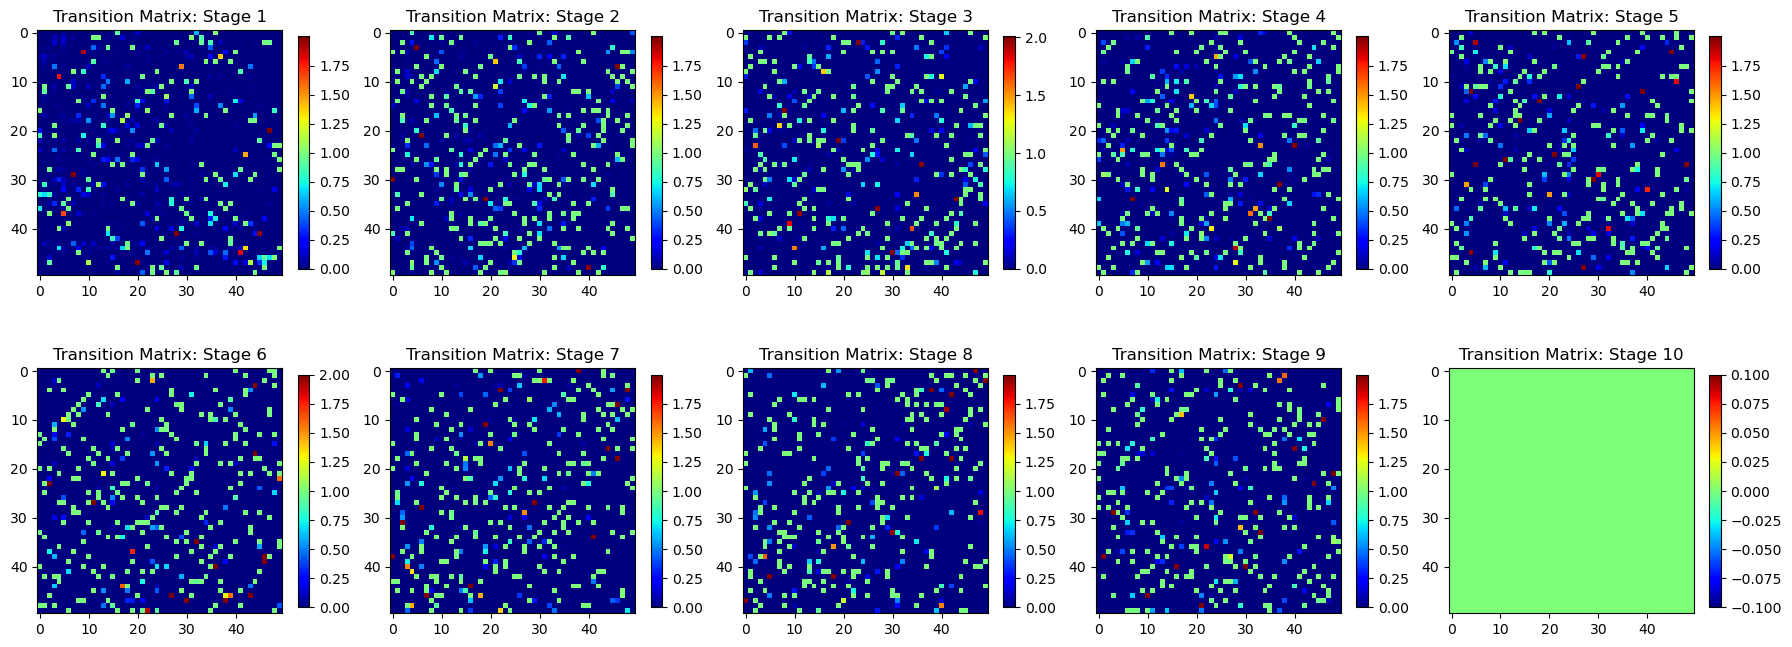

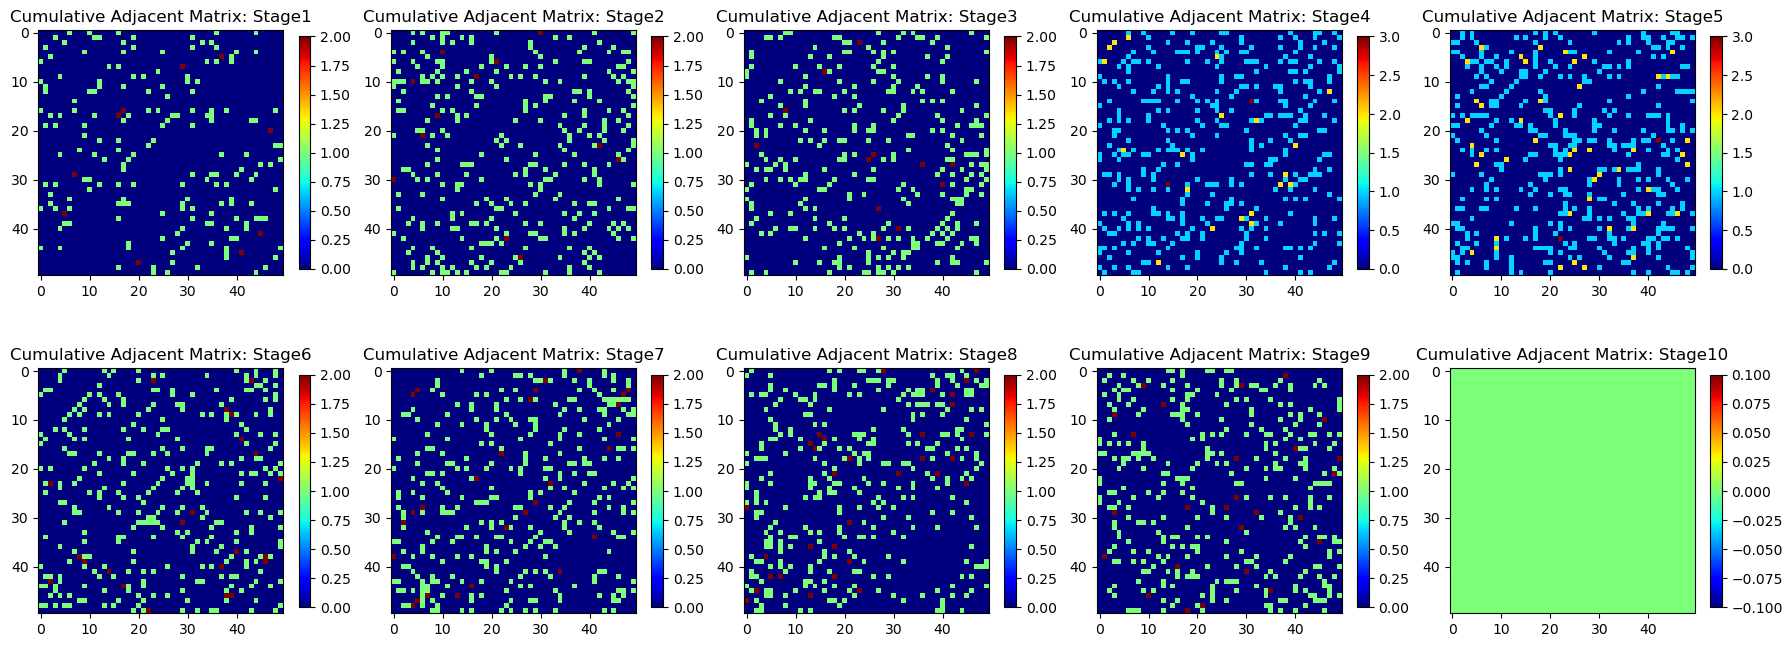

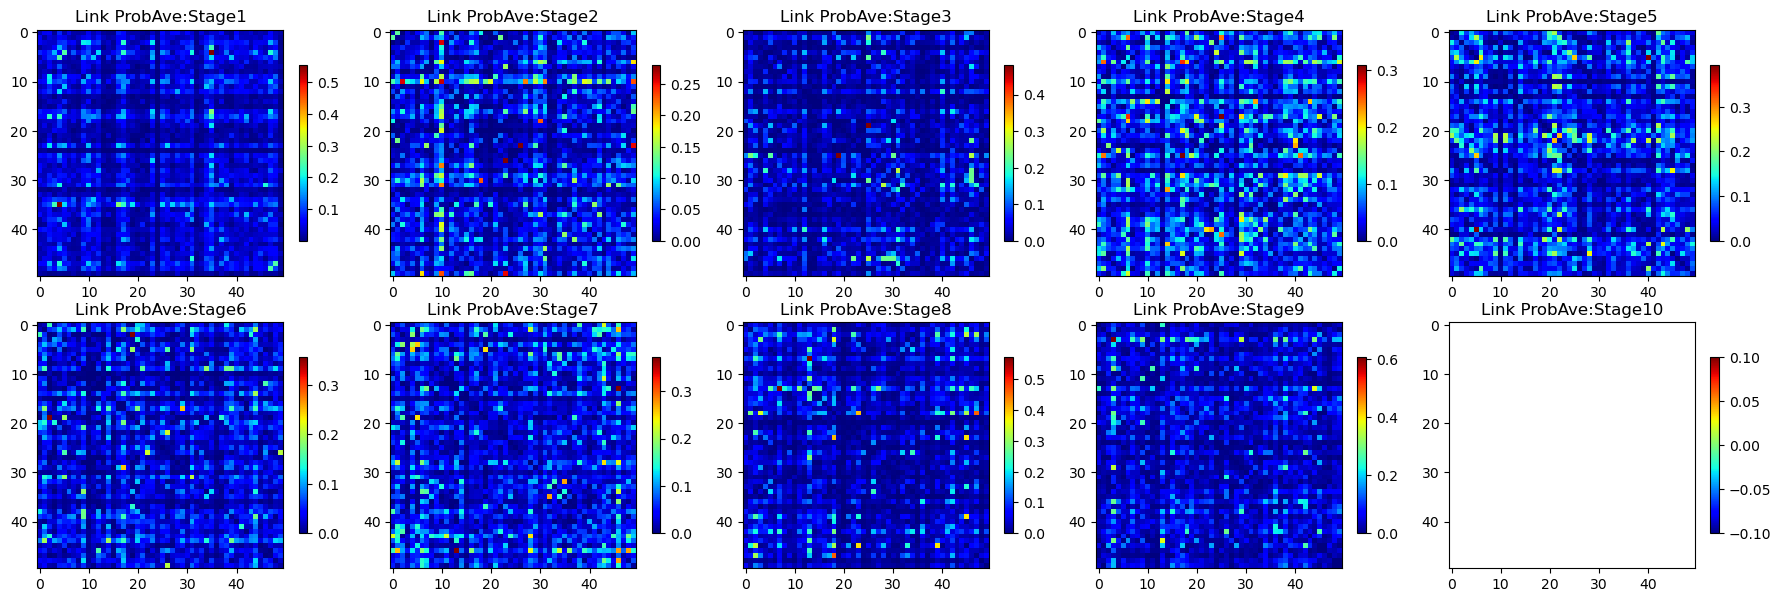

In [11]:
%matplotlib inline
transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(2, 5, figsize=(18,7))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[2:6], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*6:i*6+6], axis = 0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(2,5, figsize=(18,7))
for i,ax in enumerate(axs.flatten()):
    if i == 0:
        Z = torch.sum(gs_prgds.Z[3:6], axis = 0)
    else:
        Z = torch.sum(gs_prgds.Z[i*6:i*6+6], axis = 0)
    im = ax.imshow(Z+Z.T, cmap='jet')
    cbar = plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(f'Cumulative Adjacent Matrix: Stage{i+1}')
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(2,5, figsize = (18,6))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        ProbAve = torch.mean(gs_prgds.ProbAve[3:7], axis = 0)
    else:
        ProbAve = torch.mean(gs_prgds.ProbAve[i*6:i*6+6], axis = 0)
    im = ax.imshow(ProbAve + ProbAve.T, cmap='jet')
    ax.set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = ax, shrink=0.7)
plt.tight_layout()
plt.show()

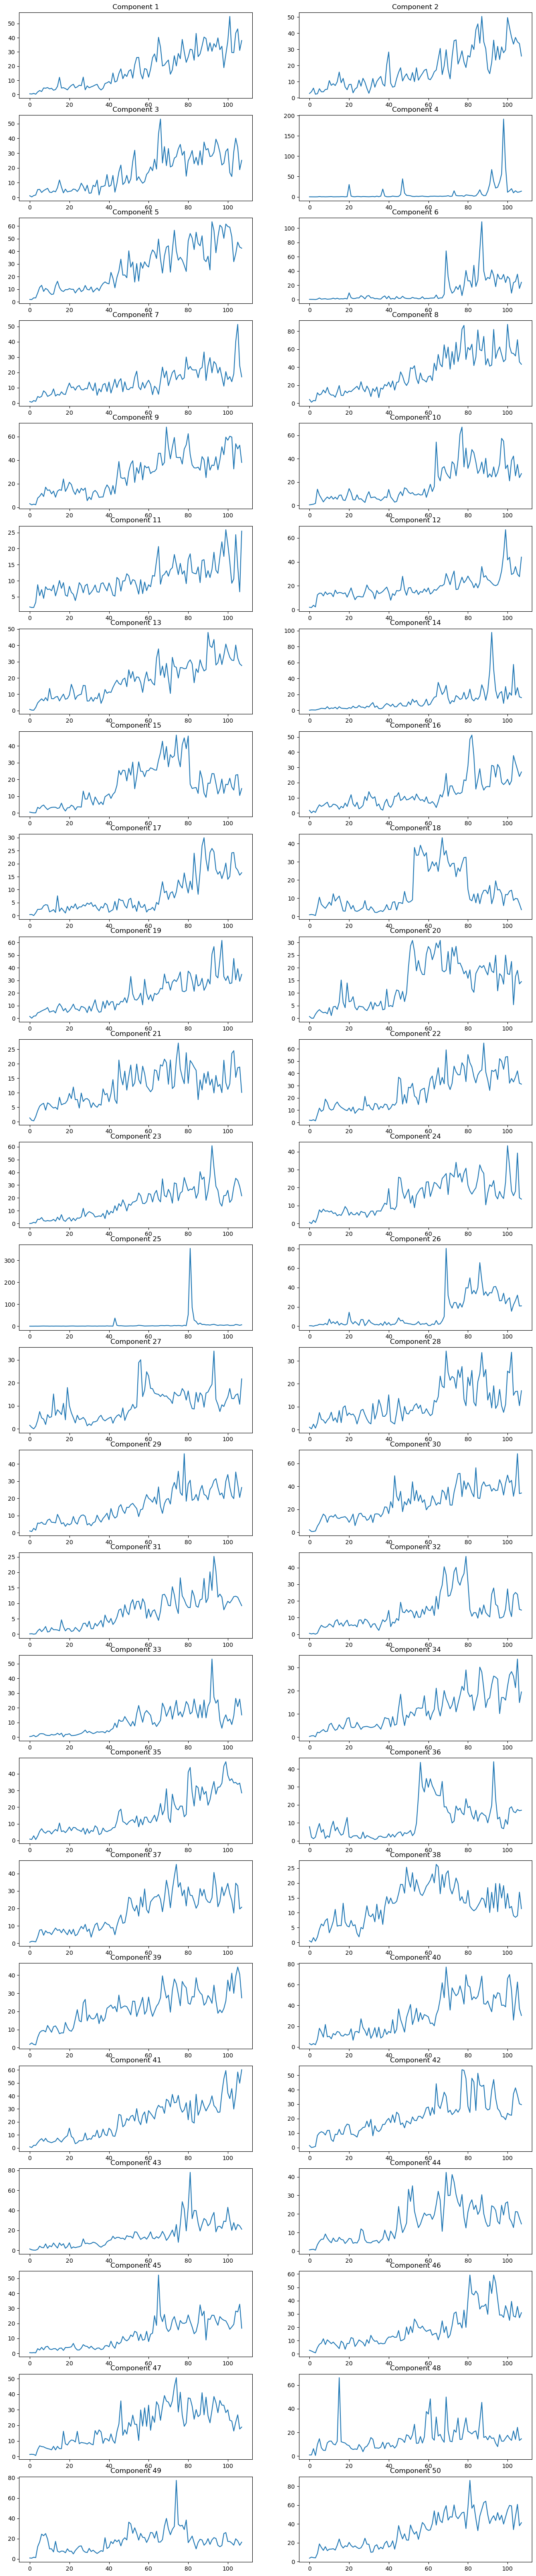

In [12]:
%matplotlib inline
fig, axs = plt.subplots(25, 2, figsize = (16,80))
for i, ax in enumerate(axs.flatten()):
    ax.plot(gs_prgds.the.T[i])
    ax.set_title('Component {}'.format(i+1))
plt.show()